Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Загружаем данные...
✅ Данные загружены
Обучающая выборка: 19200
Валидационная: 4800
Тестовая: 4000
Размер входных данных: (19200, 28, 28, 3)
Шум добавлен
🏗️ Строим модель...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,764 (366.27 KB)

 Trainable params: 93,764 (366.27 KB)

 Non-trainable params: 0 (0.00 B)


🚀 НАЧАЛО ОБУЧЕНИЯ
Epoch 1/12
150/150 ━━━━━━━━━━━━━━━━━━━━ 42s 260ms/step - accuracy: 0.6896 - loss: 0.7561 - val_accuracy: 0.8800 - val_loss: 0.3921 - learning_rate: 0.0010
Epoch 2/12
150/150 ━━━━━━━━━━━━━━━━━━━━ 45s 287ms/step - accuracy: 0.8680 - loss: 0.4051 - val_accuracy: 0.8960 - val_loss: 0.3221 - learning_rate: 0.0010
Epoch 3/12
150/150 ━━━━━━━━━━━━━━━━━━━━ 37s 245ms/step - accuracy: 0.8907 - loss: 0.3409 - val_accuracy: 0.9052 - val_loss: 0.2816 - learning_rate: 0.0010
Epoch 4/12
150/150 ━━━━━━━━━━━━━━━━━━━━ 44s 269ms/step - accuracy: 0.9013 - loss: 0.3094 - val_accuracy: 0.9158 - val_loss: 0.2646 - learning_rate: 0.0010
Epoch 5/12
150/150 ━━━━━━━━━━━━━━━━━━━━ 36s 243ms/step - accuracy: 0.9082 - loss: 0.2782 - val_accuracy: 0.9185 - val_loss: 0.2433 - learning_rate: 0.0010
Epoch 6/12
150/150 ━━━━━━━━━━━━━━━━━━━━ 46s 277ms/step - accuracy: 0.9152 - loss: 0.2601 - val_accuracy: 0.9298 - val_loss: 0.2234 - learning_rate: 0.0010
Epoch 7/12
150/150 ━━━━━━━━━━━━━━━━━━━━ 37s 246ms/s

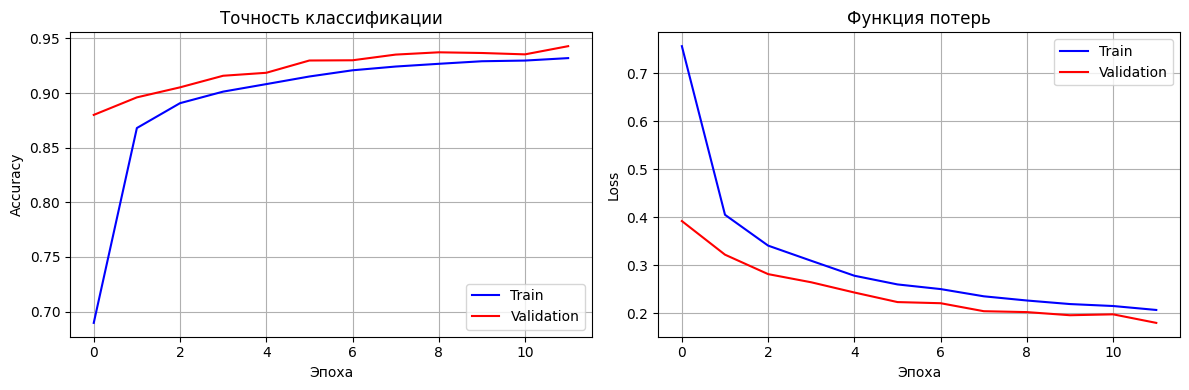


📊 РЕЗУЛЬТАТЫ
Точность на тестовой выборке: 94.63%
Loss на тестовой выборке: 0.1670


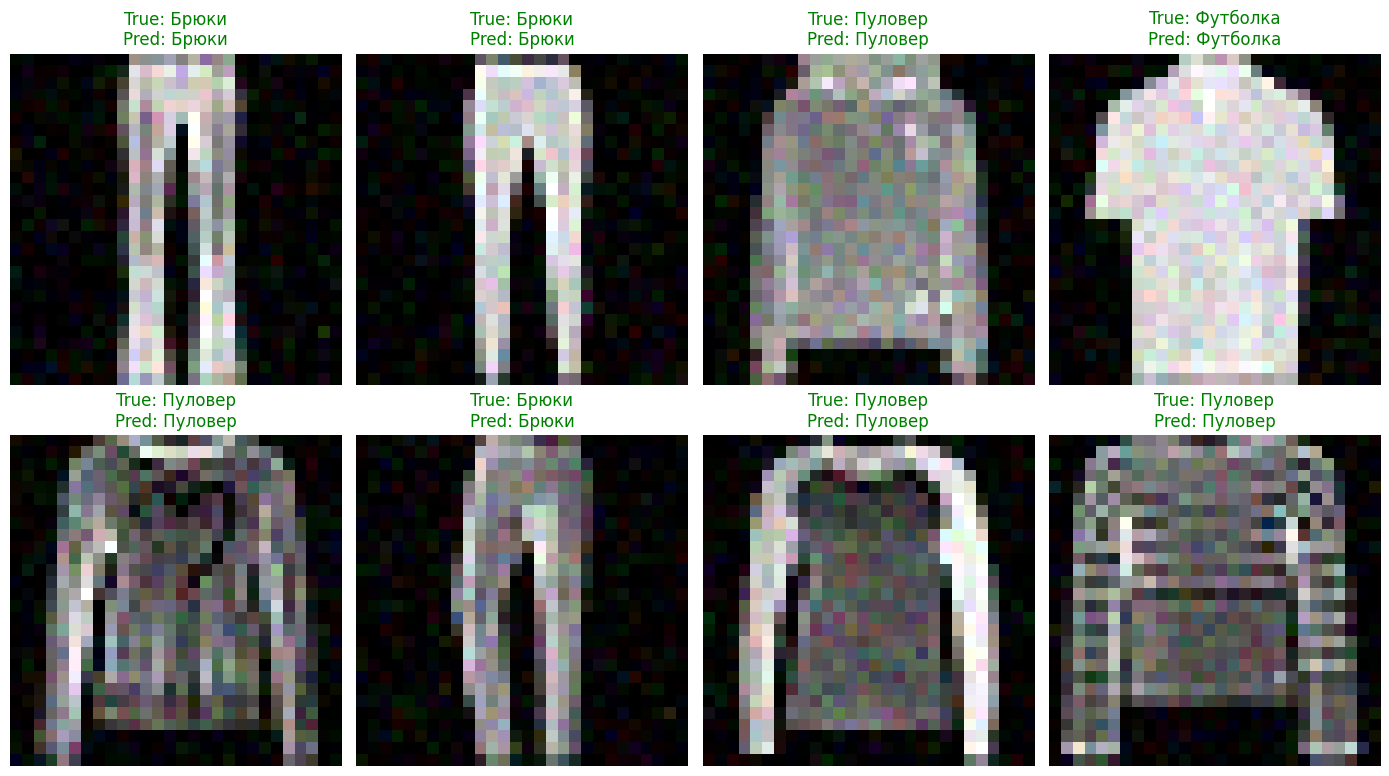


💾 Модель сохранена: /content/drive/MyDrive/Colab_Notebooks/laba4/fashion_classifier.h5


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')


print("Загружаем данные...")

if os.path.exists('fashion_mnist_data/fashion-mnist_train.csv'):
    train_df = pd.read_csv('fashion_mnist_data/fashion-mnist_train.csv')
    test_df = pd.read_csv('fashion_mnist_data/fashion-mnist_test.csv')
else:
    !kaggle datasets download -d zalando-research/fashionmnist
    !unzip -q fashionmnist.zip -d fashion_mnist_data
    train_df = pd.read_csv('fashion_mnist_data/fashion-mnist_train.csv')
    test_df = pd.read_csv('fashion_mnist_data/fashion-mnist_test.csv')

print("Данные загружены")

SELECTED_CLASSES = [0, 1, 2, 3]
class_names = ['Футболка', 'Брюки', 'Пуловер', 'Платье']
num_classes = 4

train_labels_all = train_df['label'].values
test_labels_all = test_df['label'].values

x_train_all = train_df.drop('label', axis=1).values.reshape(-1, 28, 28).astype('float32')
x_test_all = test_df.drop('label', axis=1).values.reshape(-1, 28, 28).astype('float32')

mask_train = np.isin(train_labels_all, SELECTED_CLASSES)
mask_test = np.isin(test_labels_all, SELECTED_CLASSES)

x_train_raw = x_train_all[mask_train]
y_train_raw = train_labels_all[mask_train]
x_test = x_test_all[mask_test]
y_test = test_labels_all[mask_test]

x_train_raw = x_train_raw / 255.0
x_test = x_test / 255.0

x_train, x_val, y_train, y_val = train_test_split(
    x_train_raw, y_train_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_train_raw  # сохраняем распределение классов
)

print(f"Обучающая выборка: {x_train.shape[0]}")
print(f"Валидационная: {x_val.shape[0]}")
print(f"Тестовая: {x_test.shape[0]}")

x_train = np.stack([x_train] * 3, axis=-1)
x_val = np.stack([x_val] * 3, axis=-1)
x_test = np.stack([x_test] * 3, axis=-1)

y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_val = tf.keras.utils.to_categorical(y_val, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

print(f"Размер входных данных: {x_train.shape}")

def add_mixed_noise(images):
    noise = np.random.normal(loc=0.0, scale=0.05, size=images.shape)
    noisy = images + noise
    return np.clip(noisy, 0., 1.)

x_train_noisy = add_mixed_noise(x_train)
x_val_noisy = add_mixed_noise(x_val)
x_test_noisy = add_mixed_noise(x_test)

print("Шум добавлен")

def build_simple_cnn(input_shape=(28,28,3), num_classes=4):
    """Простая CNN для быстрого обучения"""

    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)  # вместо Flatten + Dense

    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

print("Строим модель...")
model = build_simple_cnn()
model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

print("\nНАЧАЛО ОБУЧЕНИЯ")
print("=" * 50)

history = model.fit(
    x_train_noisy,
    y_train,
    epochs=12,
    batch_size=128,
    validation_data=(x_val_noisy, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], 'b-', label='Train')
plt.plot(history.history['val_accuracy'], 'r-', label='Validation')
plt.title('Точность классификации')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], 'b-', label='Train')
plt.plot(history.history['val_loss'], 'r-', label='Validation')
plt.title('Функция потерь')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

test_loss, test_acc = model.evaluate(x_test_noisy, y_test, verbose=0)

print("\n" + "=" * 50)
print("РЕЗУЛЬТАТЫ")
print("=" * 50)
print(f"Точность на тестовой выборке: {test_acc:.2%}")
print(f"Loss на тестовой выборке: {test_loss:.4f}")

def show_predictions():
    indices = np.random.choice(len(x_test), 8, replace=False)
    preds = model.predict(x_test_noisy[indices], verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = np.argmax(y_test[indices], axis=1)

    plt.figure(figsize=(14, 8))
    for i, idx in enumerate(indices):
        plt.subplot(2, 4, i+1)
        plt.imshow(x_test_noisy[idx], cmap='gray')
        color = 'green' if pred_classes[i] == true_classes[i] else 'red'
        plt.title(f'True: {class_names[true_classes[i]]}\nPred: {class_names[pred_classes[i]]}', color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_predictions()

save_dir = '/content/drive/MyDrive/Colab_Notebooks/laba4/'
os.makedirs(save_dir, exist_ok=True)

model.save(os.path.join(save_dir, 'fashion_classifier.h5'))
print(f"\nМодель сохранена: {save_dir}fashion_classifier.h5")